# Week 11 Notebook 3: Multimodal Pipeline Demo

This notebook supports the **Vision and Multimodal Intelligence** part of the lecture.

## What this notebook covers
- Building a simple end-to-end multimodal pipeline
- Image upload / intake logic
- OCR extraction
- Rule-based postprocessing
- Safety / moderation gate
- Final structured output for a user-facing feature

## Lecture sections
- Section 9: Building Multimodal Pipelines
- Section 10: Image Upload and Processing Flow
- Section 11: Moderation and Safety in Vision Systems

## Overall flow
1. Start with a user-uploaded image.
2. Validate the file and basic metadata.
3. Run a moderation / routing gate.
4. Extract text from the image.
5. Parse useful fields.
6. Produce a final structured feature output.



## 0. Setup

This notebook uses:
- **PIL** for image handling
- **matplotlib** for display
- **pytesseract** for OCR if available
- simple Python logic for parsing, routing, and moderation simulation

If OCR is unavailable, the notebook falls back to a prepared transcript.


In [1]:
# Uncomment if needed
# !pip install pillow matplotlib pytesseract

from pathlib import Path
import re
from dataclasses import dataclass, asdict
from typing import List, Dict, Any, Optional

from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

print("Notebook 3 setup complete.")


Notebook 3 setup complete.


## 1. Create Demo Input Images

To make this lecture reliable, we generate demo images in code:
- a receipt image (safe, processable)
- a fake warning image to simulate moderation logic


In [2]:
demo_dir = Path("demo_images")
demo_dir.mkdir(exist_ok=True)

receipt_path = demo_dir / "pipeline_receipt.png"
warning_path = demo_dir / "warning_image.png"

# Receipt image
w, h = 900, 700
img = Image.new("RGB", (w, h), "white")
draw = ImageDraw.Draw(img)

try:
    font = ImageFont.truetype("DejaVuSans.ttf", 28)
    font_bold = ImageFont.truetype("DejaVuSans-Bold.ttf", 34)
except:
    font = ImageFont.load_default()
    font_bold = ImageFont.load_default()

receipt_lines = [
    ("Campus Market", font_bold),
    ("123 Green St, Urbana, IL", font),
    ("----------------------------------------", font),
    ("Milk                1 x $3.49", font),
    ("Bread               1 x $2.99", font),
    ("Eggs                1 x $4.29", font),
    ("Bananas             2 x $0.79", font),
    ("----------------------------------------", font),
    ("Subtotal                $12.35", font),
    ("Tax                      $1.05", font),
    ("Total                   $13.40", font_bold),
    ("Date: 04/01/2026", font),
]

y = 40
for text, fnt in receipt_lines:
    draw.text((50, y), text, fill="black", font=fnt)
    y += 50

img.save(receipt_path)

# Warning image for moderation simulation
img2 = Image.new("RGB", (800, 500), (245, 245, 245))
draw2 = ImageDraw.Draw(img2)
draw2.rectangle((40, 40, 760, 460), outline="red", width=8)
draw2.text((90, 120), "Sensitive Example", fill="red", font=font_bold)
draw2.text((90, 220), "Use this image to demonstrate", fill="black", font=font)
draw2.text((90, 270), "moderation / routing logic.", fill="black", font=font)
img2.save(warning_path)

receipt_path, warning_path


(PosixPath('demo_images/pipeline_receipt.png'),
 PosixPath('demo_images/warning_image.png'))

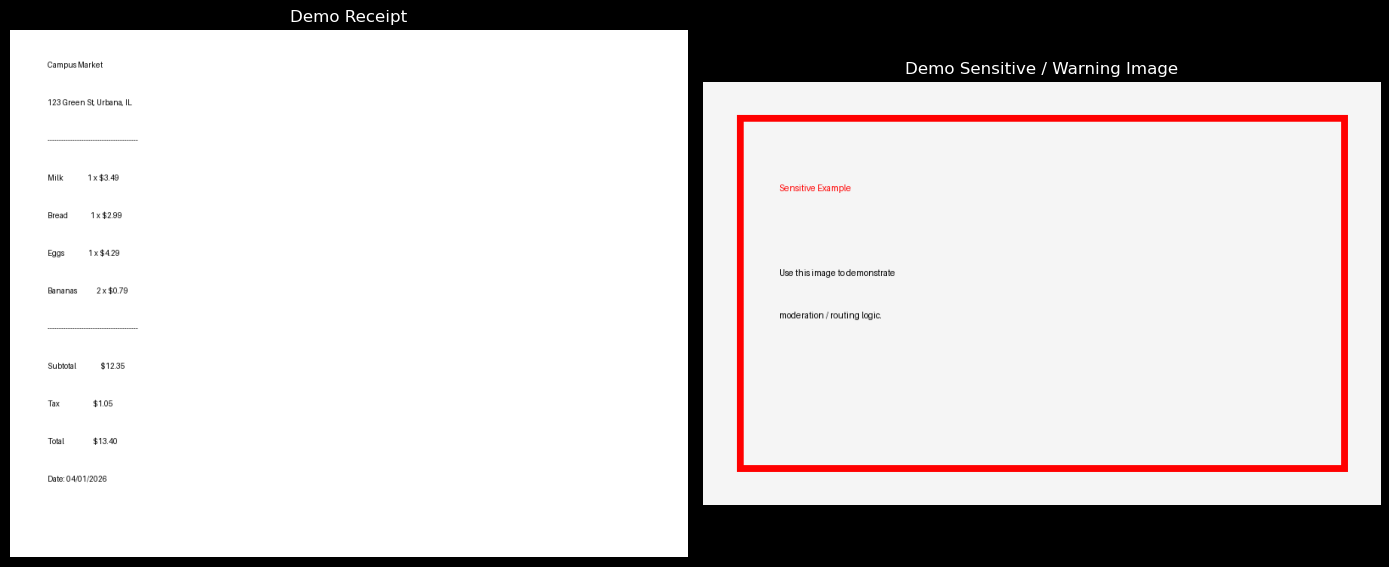

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(Image.open(receipt_path))
axes[0].set_title("Demo Receipt")
axes[0].axis("off")

axes[1].imshow(Image.open(warning_path))
axes[1].set_title("Demo Sensitive / Warning Image")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## 2. Section 10 Demo: Image Upload and Intake

In a real product, an image enters the system through an upload flow.

The backend should validate:
- file exists
- format is supported
- dimensions are acceptable
- file is processable

This is where production systems begin, not at the model.


In [4]:
SUPPORTED_FORMATS = {".png", ".jpg", ".jpeg", ".webp"}

def validate_image(path: Path) -> Dict[str, Any]:
    result = {
        "path": str(path),
        "exists": path.exists(),
        "format_ok": False,
        "size_ok": False,
        "width": None,
        "height": None,
        "status": "invalid"
    }

    if not path.exists():
        return result

    result["format_ok"] = path.suffix.lower() in SUPPORTED_FORMATS

    try:
        img = Image.open(path)
        result["width"], result["height"] = img.size
        result["size_ok"] = (img.size[0] >= 100 and img.size[1] >= 100)
    except Exception:
        return result

    if result["exists"] and result["format_ok"] and result["size_ok"]:
        result["status"] = "valid"

    return result

print(validate_image(receipt_path))
print(validate_image(warning_path))


{'path': 'demo_images/pipeline_receipt.png', 'exists': True, 'format_ok': True, 'size_ok': True, 'width': 900, 'height': 700, 'status': 'valid'}
{'path': 'demo_images/warning_image.png', 'exists': True, 'format_ok': True, 'size_ok': True, 'width': 800, 'height': 500, 'status': 'valid'}


### Note
This is a simple but important systems lesson:

> Upload handling is part of the AI pipeline.

The model never sees the file unless the system first accepts it.


## 3. Section 11 Demo: Moderation / Safety Gate

Before a system processes user-uploaded content deeply, it often performs a safety or policy check.

In production, this might use:
- a moderation model
- a content safety API
- metadata or heuristic rules

For lecture clarity, we simulate a moderation gate.


In [5]:
def moderation_gate(path: Path) -> Dict[str, Any]:
    # Simple simulation for teaching:
    # route anything with "warning" in the file name to review
    # otherwise allow
    filename = path.name.lower()

    if "warning" in filename or "sensitive" in filename:
        return {
            "decision": "review",
            "reason": "Potentially sensitive content; send to human or secondary review",
            "confidence": 0.88
        }
    else:
        return {
            "decision": "allow",
            "reason": "No obvious safety concern in this demo",
            "confidence": 0.93
        }

print("Receipt gate:", moderation_gate(receipt_path))
print("Warning gate:", moderation_gate(warning_path))


Receipt gate: {'decision': 'allow', 'reason': 'No obvious safety concern in this demo', 'confidence': 0.93}
Warning gate: {'decision': 'review', 'reason': 'Potentially sensitive content; send to human or secondary review', 'confidence': 0.88}


### Note
Moderation scores become **routing decisions**:
- allow
- block
- review

This is where confidence thresholds become product policy.


## 4. OCR Stage

If the image is allowed, the next stage extracts visible text.
This is the same OCR logic from Notebook 2, now embedded inside a pipeline.


In [6]:
def run_ocr(path: Path) -> str:
    try:
        import pytesseract
        text = pytesseract.image_to_string(Image.open(path))
        if text and text.strip():
            return text.strip()
    except Exception:
        pass

    # Fallback transcript for lecture reliability
    if "receipt" in path.name.lower():
        return '''
Campus Market
123 Green St, Urbana, IL

Milk                1 x $3.49
Bread               1 x $2.99
Eggs                1 x $4.29
Bananas             2 x $0.79

Subtotal                $12.35
Tax                      $1.05
Total                   $13.40
Date: 04/01/2026
'''.strip()
    return ""

receipt_ocr = run_ocr(receipt_path)
print(receipt_ocr)


Campus Market

128Green St Urbana, IL

Milk 1383.49

Bread 1x$299

Eggs 1x$429

Bananas 2x 80.79

Subtotal $12.95
Tax $105
Tol $13.40

Date: 04/01/2028


## 5. Postprocessing: Parse Useful Fields

OCR text is raw evidence.
Most product features need:
- merchant
- items
- totals
- date
- maybe a higher-level summary

So we add parsing logic.


In [7]:
@dataclass
class ReceiptItem:
    name: str
    quantity: Optional[int]
    unit_price: Optional[float]

@dataclass
class ReceiptResult:
    merchant: Optional[str]
    items: List[ReceiptItem]
    subtotal: Optional[float]
    tax: Optional[float]
    total: Optional[float]
    date: Optional[str]
    summary: Optional[str]

def parse_receipt_text(text: str) -> ReceiptResult:
    lines = [line.strip() for line in text.splitlines() if line.strip()]

    merchant = lines[0] if lines else None

    subtotal = None
    tax = None
    total = None
    date = None
    items = []

    money_pattern = re.compile(r"\$\s*([0-9]+\.[0-9]{2})")
    item_pattern = re.compile(r"^(.*?)(\d+)\s*x\s*\$([0-9]+\.[0-9]{2})$")

    for line in lines:
        lower = line.lower()

        if lower.startswith("subtotal"):
            m = money_pattern.search(line)
            if m:
                subtotal = float(m.group(1))

        elif lower.startswith("tax"):
            m = money_pattern.search(line)
            if m:
                tax = float(m.group(1))

        elif lower.startswith("total"):
            m = money_pattern.search(line)
            if m:
                total = float(m.group(1))

        elif lower.startswith("date"):
            parts = line.split(":", 1)
            if len(parts) == 2:
                date = parts[1].strip()

        else:
            m = item_pattern.match(line.replace("  ", " "))
            if m:
                name = m.group(1).strip()
                qty = int(m.group(2))
                price = float(m.group(3))
                items.append(ReceiptItem(name=name, quantity=qty, unit_price=price))

    summary = None
    if merchant and total is not None:
        item_names = ", ".join([item.name for item in items]) if items else "multiple items"
        summary = f"This receipt is from {merchant}. Items include {item_names}. Final total: ${total:.2f}."

    return ReceiptResult(
        merchant=merchant,
        items=items,
        subtotal=subtotal,
        tax=tax,
        total=total,
        date=date,
        summary=summary
    )

parsed = parse_receipt_text(receipt_ocr)
parsed


ReceiptResult(merchant='Campus Market', items=[], subtotal=12.95, tax=None, total=None, date='04/01/2028', summary=None)

In [8]:
parsed_dict = {
    "merchant": parsed.merchant,
    "items": [asdict(item) for item in parsed.items],
    "subtotal": parsed.subtotal,
    "tax": parsed.tax,
    "total": parsed.total,
    "date": parsed.date,
    "summary": parsed.summary,
}
parsed_dict


{'merchant': 'Campus Market',
 'items': [],
 'subtotal': 12.95,
 'tax': None,
 'total': None,
 'date': '04/01/2028',
 'summary': None}

## 6. Section 9 Demo: Turn Stages into a Full Pipeline

Now we combine:
- upload validation
- moderation gate
- OCR
- parsing
- user-facing structured output

This is the key systems transition.


In [9]:
def process_uploaded_image(path: Path) -> Dict[str, Any]:
    intake = validate_image(path)
    if intake["status"] != "valid":
        return {
            "status": "failed",
            "stage": "intake",
            "details": intake
        }

    moderation = moderation_gate(path)
    if moderation["decision"] == "review":
        return {
            "status": "review",
            "stage": "moderation",
            "details": moderation
        }

    text = run_ocr(path)
    parsed_result = parse_receipt_text(text)

    return {
        "status": "success",
        "stage": "complete",
        "intake": intake,
        "moderation": moderation,
        "ocr_text": text,
        "parsed_output": {
            "merchant": parsed_result.merchant,
            "items": [asdict(item) for item in parsed_result.items],
            "subtotal": parsed_result.subtotal,
            "tax": parsed_result.tax,
            "total": parsed_result.total,
            "date": parsed_result.date,
            "summary": parsed_result.summary,
        }
    }

receipt_result = process_uploaded_image(receipt_path)
warning_result = process_uploaded_image(warning_path)

receipt_result, warning_result


({'status': 'success',
  'stage': 'complete',
  'intake': {'path': 'demo_images/pipeline_receipt.png',
   'exists': True,
   'format_ok': True,
   'size_ok': True,
   'width': 900,
   'height': 700,
   'status': 'valid'},
  'moderation': {'decision': 'allow',
   'reason': 'No obvious safety concern in this demo',
   'confidence': 0.93},
  'ocr_text': 'Campus Market\n\n128Green St Urbana, IL\n\nMilk 1383.49\n\nBread 1x$299\n\nEggs 1x$429\n\nBananas 2x 80.79\n\nSubtotal $12.95\nTax $105\nTol $13.40\n\nDate: 04/01/2028',
  'parsed_output': {'merchant': 'Campus Market',
   'items': [],
   'subtotal': 12.95,
   'tax': None,
   'total': None,
   'date': '04/01/2028',
   'summary': None}},
 {'status': 'review',
  'stage': 'moderation',
  'details': {'decision': 'review',
   'reason': 'Potentially sensitive content; send to human or secondary review',
   'confidence': 0.88}})

## 7. Display Final User-Facing Outputs

This is what matters for product design:
- what does the user see?
- what does the system store?
- what happens on borderline content?


In [10]:
print("SAFE RECEIPT RESULT:\n")
for k, v in receipt_result.items():
    print(f"{k}: {v}")


SAFE RECEIPT RESULT:

status: success
stage: complete
intake: {'path': 'demo_images/pipeline_receipt.png', 'exists': True, 'format_ok': True, 'size_ok': True, 'width': 900, 'height': 700, 'status': 'valid'}
moderation: {'decision': 'allow', 'reason': 'No obvious safety concern in this demo', 'confidence': 0.93}
ocr_text: Campus Market

128Green St Urbana, IL

Milk 1383.49

Bread 1x$299

Eggs 1x$429

Bananas 2x 80.79

Subtotal $12.95
Tax $105
Tol $13.40

Date: 04/01/2028
parsed_output: {'merchant': 'Campus Market', 'items': [], 'subtotal': 12.95, 'tax': None, 'total': None, 'date': '04/01/2028', 'summary': None}


In [11]:
print("WARNING / REVIEW RESULT:\n")
for k, v in warning_result.items():
    print(f"{k}: {v}")


WARNING / REVIEW RESULT:

status: review
stage: moderation
details: {'decision': 'review', 'reason': 'Potentially sensitive content; send to human or secondary review', 'confidence': 0.88}


### Note
It is important to understand:

> the same pipeline can produce different system states:
- success
- review
- failure

This is real system behavior, not just model output.


## 8. Optional Feature Layer: Spending Category

A product rarely stops at extraction.
You often add one more logic layer that creates a user-facing feature.


In [12]:
def assign_spending_category(items: List[Dict[str, Any]]) -> str:
    names = " ".join(item["name"].lower() for item in items)
    if any(word in names for word in ["milk", "bread", "eggs", "bananas"]):
        return "Groceries"
    return "General"

if receipt_result["status"] == "success":
    category = assign_spending_category(receipt_result["parsed_output"]["items"])
    receipt_result["parsed_output"]["category"] = category

receipt_result["parsed_output"]


{'merchant': 'Campus Market',
 'items': [],
 'subtotal': 12.95,
 'tax': None,
 'total': None,
 'date': '04/01/2028',
 'summary': None,
 'category': 'General'}

## 9. Pipeline Summary Table


In [13]:
pipeline_rows = [
    ("Upload / Intake", "Validate file exists, format, and size"),
    ("Moderation Gate", "Allow, block, or review image"),
    ("OCR", "Extract visible text"),
    ("Parsing / Logic", "Convert text into fields"),
    ("Feature Layer", "Add user-facing value such as category or summary"),
    ("Output", "Return structured result to user"),
]

print(f'{"Stage":20s} | {"Purpose"}')
print("-"*70)
for stage, purpose in pipeline_rows:
    print(f"{stage:20s} | {purpose}")


Stage                | Purpose
----------------------------------------------------------------------
Upload / Intake      | Validate file exists, format, and size
Moderation Gate      | Allow, block, or review image
OCR                  | Extract visible text
Parsing / Logic      | Convert text into fields
Feature Layer        | Add user-facing value such as category or summary
Output               | Return structured result to user


## 10. Mini Lecture Wrap-Up

Notebook 3 demonstrated:

1. **Multimodal systems are multi-stage pipelines**
2. **Image upload and validation happen before AI inference**
3. **Moderation is a routing layer**
4. **OCR is only one stage, not the full feature**
5. **The final value comes from turning extracted signals into product behavior**